In [1]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
seed_list = range(1,6)
scheme_list = ["dringsu2","rrgsu2","ls"]
sw_list = range(40,101,20)

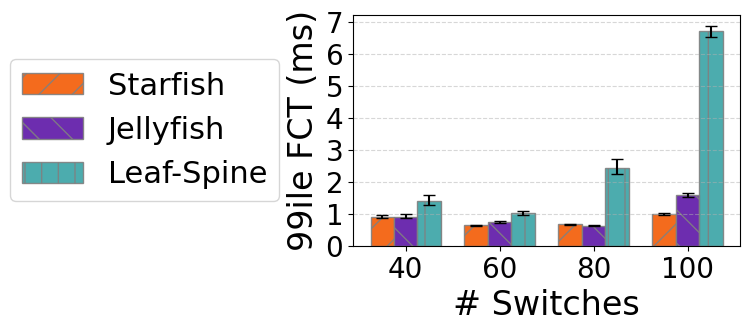

In [7]:
import matplotlib.pyplot as plt
import numpy as np

hatch_patterns = ['/', '\\', '|', '-', '+', 'x', '.', '*']
plotlabeldict = {"dringsu2":"Starfish","rrgsu2":"Jellyfish","ls":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","rrgsu2":"#5d16a6","ls":"#38a3a5"}


# Load data from txt
plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile, 'r') as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        p99 = float(tokens[3])  # 99th percentile FCT
        plotdatadict[outfile] = p99

# Define your schemes, switch counts, and seeds
# scheme_list = ["dringsu2", "rrgsu2", "ls"]
# sw_list = list(range(40, 101, 20))  # [40, 60, 80, 100]
# seed_list = list(range(1, 6))       # [1, 2, 3, 4, 5]

# Prepare data
bar_data = {}  # bar_data[scheme] = list of (mean, lower_err, upper_err) per sw

for scheme in scheme_list:
    stats = []
    for sw in sw_list:
        fct_list = []
        for seed in seed_list:
            outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"
            p99 = plotdatadict[outfile]
            fct_list.append(p99)
        mean = np.mean(fct_list)
        lower = mean - min(fct_list)
        upper = max(fct_list) - mean
        stats.append((mean, lower, upper))
    bar_data[scheme] = stats

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(5, 3))
bar_width = 0.25
x = np.arange(len(sw_list))
# hatch_patterns = ['/', '\\', 'x']

for i, scheme in enumerate(scheme_list):
    means = [bar_data[scheme][j][0] for j in range(len(sw_list))]
    lower_err = [bar_data[scheme][j][1] for j in range(len(sw_list))]
    upper_err = [bar_data[scheme][j][2] for j in range(len(sw_list))]
    err = [lower_err, upper_err]
    ax.bar(x + i * bar_width, means, bar_width, yerr=err,
           label=plotlabeldict[scheme], color=plotcolordict[scheme], capsize=4, alpha=0.9, hatch=hatch_patterns[i], edgecolor='gray')

# Formatting
ax.set_xticks(x + bar_width)
ax.set_xticklabels(sw_list)
ax.set_xlabel("# Switches", fontsize=24)
ax.set_ylabel("99ile FCT (ms)", fontsize=24)
# ax.set_title("Grouped Bar Chart of 99th Percentile FCT")
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.set_yticks(range(8))
ax.tick_params(axis='both', labelsize=20)
ax.legend(loc='center right', bbox_to_anchor=(-0.15, 0.5), ncol=1, fontsize=22)
# plt.tight_layout()
plt.savefig(f"poster_scale_supernode.pdf", dpi=600, bbox_inches='tight')
